### Bab 3 - Eksplorasi Data
Dari dataset tersebut, lakukan:
1.	Informasi awal mengenai kondisi data yang meliputi total baris, banyak variabel, null identification, tipe data.
2.	Lakukan pengukuran statistik yang sesuai dengan karakteristik dan tipe data dari masing-masing variabel tanpa melibatkan data null (kosong) sehingga, untuk pengukuran statistik ini, bisa jadi tiap variabel memiliki jumlah baris yang berbeda (sesuai banyaknya null)
3.	Lakukan visualisasi data yang sesuai dengan karakteristik dan tipe data dari semua variabel 
4.	Lakukan pengukuran statistik & visualisasi data seperti nomor 2 & 3, namun dikelompokkan menurut kategori diagnose penyakit, yaitu DM Type 2 dan DM Type 2 + Penyerta.
5.	Lakukan pengujian korelasi Pearson untuk variabel-variabel numeric pada data tersebut
6.	Deteksi outlier dengan formula lower & upper bound berdasarkan masing-masing kategori diagnose penyakit.
##### Setup dan Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('DATASET_TA1(Sheet1).csv', sep=';', decimal=',')

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

##### SOAL 1: Informasi Awal

In [4]:
print(f"Total Baris dan Kolom: {df.shape}")
print("\nTipe Data:")
print(df.dtypes)
print("\nIdentifikasi Null:")
print(df.isnull().sum())

Total Baris dan Kolom: (1641, 10)

Tipe Data:
Gender         object
Age             int64
Diagnose       object
Hemoglobin    float64
Hematokrit    float64
Lekosit       float64
Eritrosit     float64
Trombosit     float64
HbA1c         float64
RBG           float64
dtype: object

Identifikasi Null:
Gender          0
Age             0
Diagnose        0
Hemoglobin     98
Hematokrit     98
Lekosit        98
Eritrosit      98
Trombosit      99
HbA1c         600
RBG           123
dtype: int64


##### SOAL 2: Pengukuran Statistik (Tanpa Null)

In [6]:
print("Statistik Deskriptif Numerik:")
print(df[num_cols].describe()) # .describe() mengabaikan nilai NaN
print("\nStatistik Deskriptif Kategorikal:")
print(df[cat_cols].describe())

Statistik Deskriptif Numerik:
               Age   Hemoglobin   Hematokrit        Lekosit    Eritrosit  \
count  1641.000000  1543.000000  1543.000000    1543.000000  1543.000000   
mean     55.277270    12.646533    37.304219   15651.315619     4.496818   
std      13.386762     2.569420     7.413016   21497.581513     0.891535   
min       1.000000     2.100000     4.900000    1000.000000     0.360000   
25%      49.000000    11.100000    32.700000    8225.000000     3.970000   
50%      56.000000    12.700000    37.800000   11740.000000     4.520000   
75%      64.000000    14.400000    42.400000   17405.000000     5.060000   
max      89.000000    25.000000    61.900000  424000.000000     9.370000   

          Trombosit        HbA1c          RBG  
count  1.542000e+03  1041.000000  1518.000000  
mean   3.404330e+05    11.712027   363.283597  
std    1.540619e+05    21.293755   237.255857  
min    4.300000e+03     3.300000     2.000000  
25%    2.452500e+05     8.500000   202.000000

##### SOAL 3: Visualisasi Data Semua Variabel

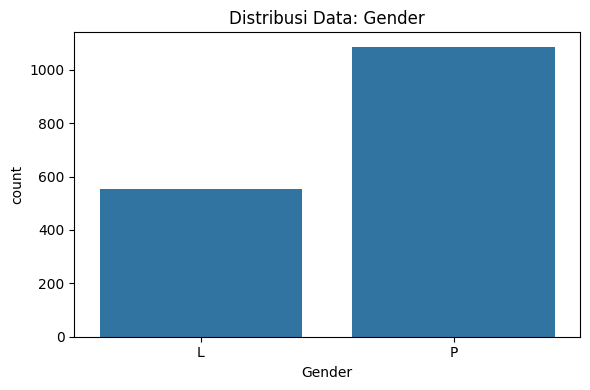

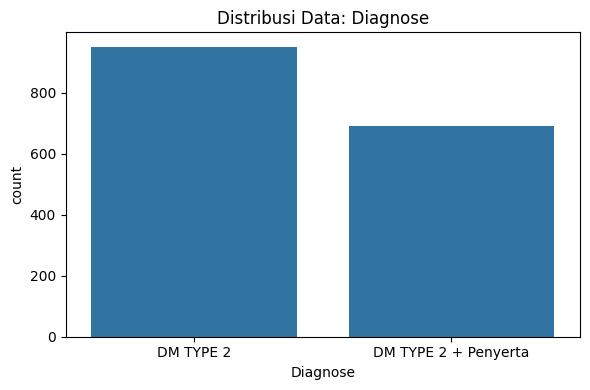

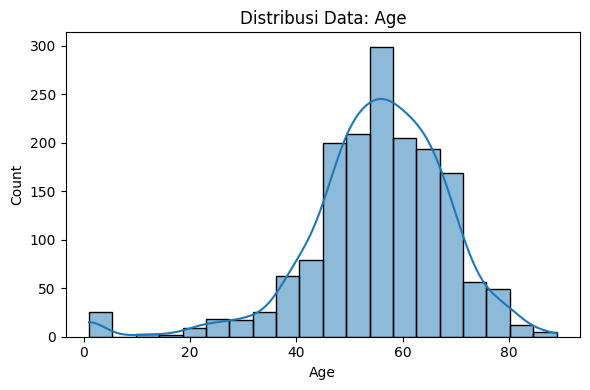

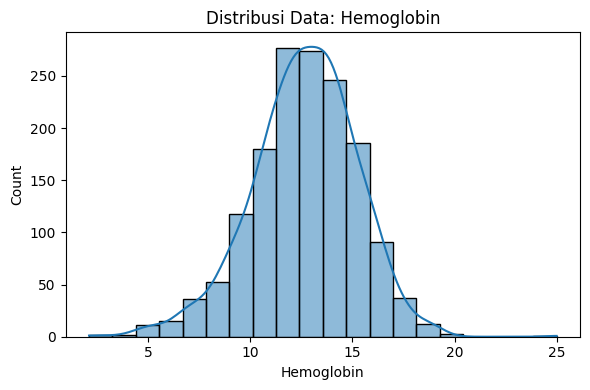

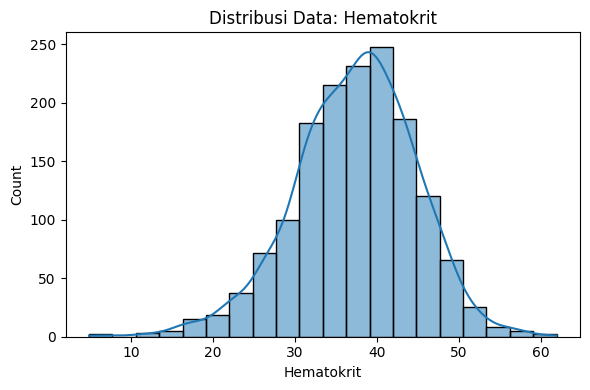

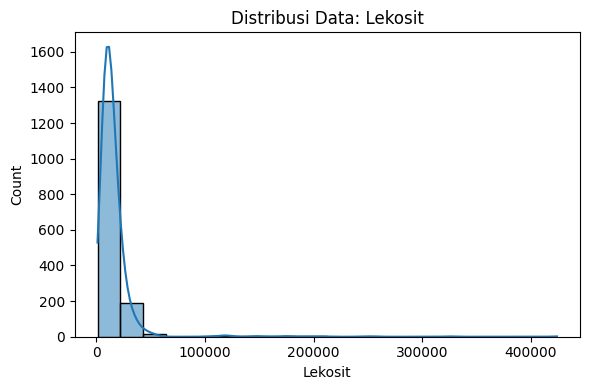

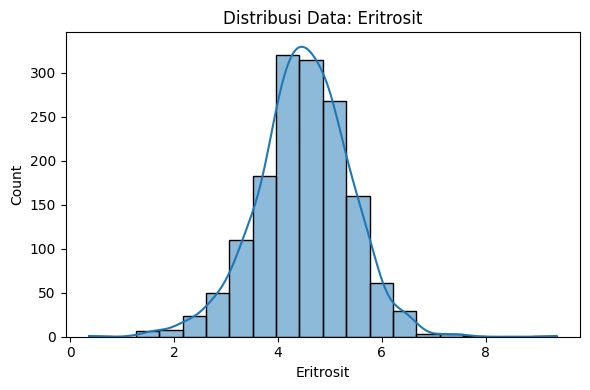

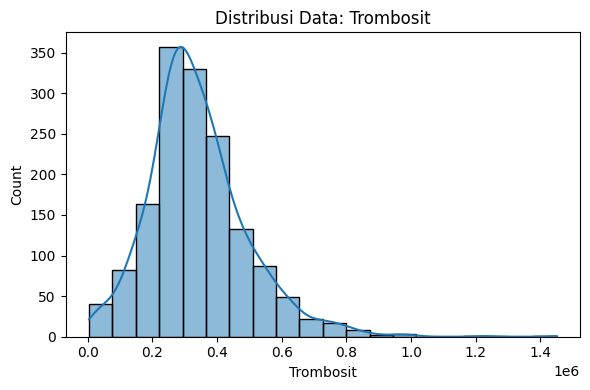

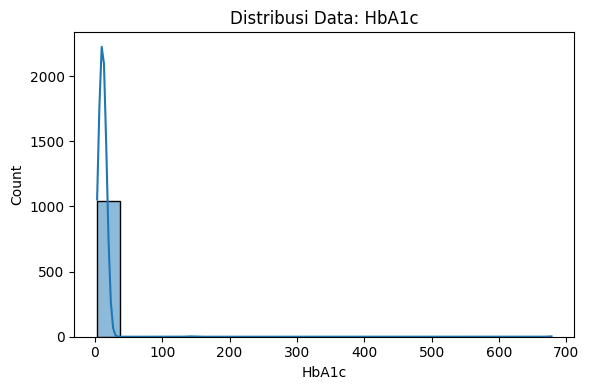

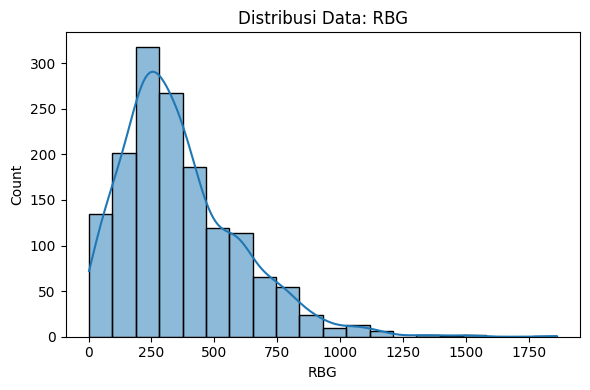

In [7]:
# Visualisasi data kategorikal (Bar Chart)
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribusi Data: {col}')
    plt.tight_layout()
    plt.show()

# Visualisasi data numerikal (Histogram)
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True, bins=20)
    plt.title(f'Distribusi Data: {col}')
    plt.tight_layout()
    plt.show()

##### SOAL 4: Statistik & Visualisasi Berdasarkan Diagnose

Statistik Berdasarkan Diagnose:
                        Age                                               \
                      count       mean        std  min   25%   50%   75%   
Diagnose                                                                   
DM TYPE 2             951.0  55.394322  13.040630  1.0  49.0  56.0  64.0   
DM TYPE 2 + Penyerta  690.0  55.115942  13.857597  1.0  49.0  57.0  64.0   

                           Hemoglobin             ... HbA1c           RBG  \
                       max      count       mean  ...   75%    max  count   
Diagnose                                          ...                       
DM TYPE 2             89.0      856.0  12.699182  ...  13.8  678.0  841.0   
DM TYPE 2 + Penyerta  88.0      687.0  12.580932  ...  14.0  142.0  677.0   

                                                                         \
                            mean         std   min    25%    50%    75%   
Diagnose                                           

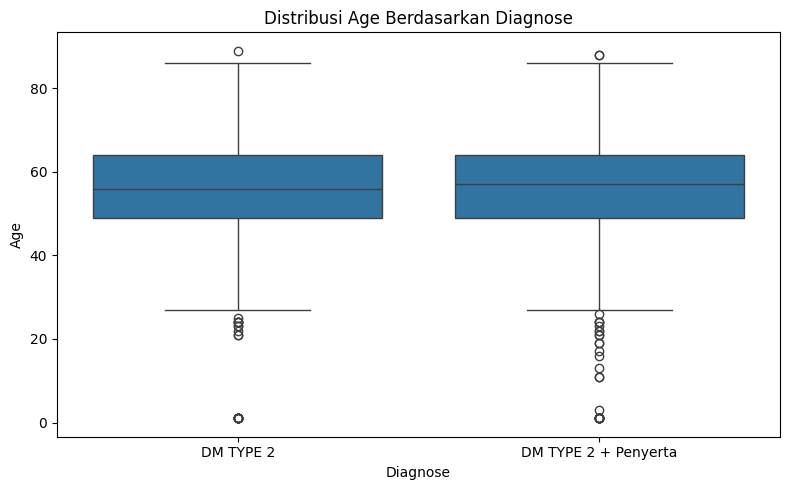

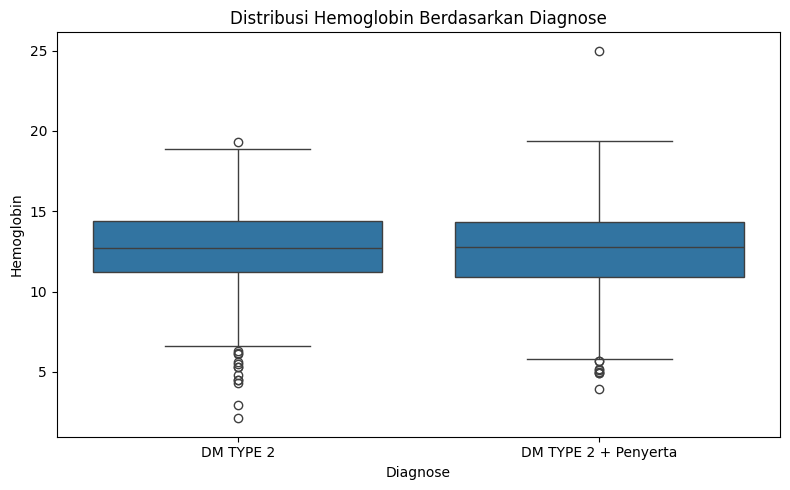

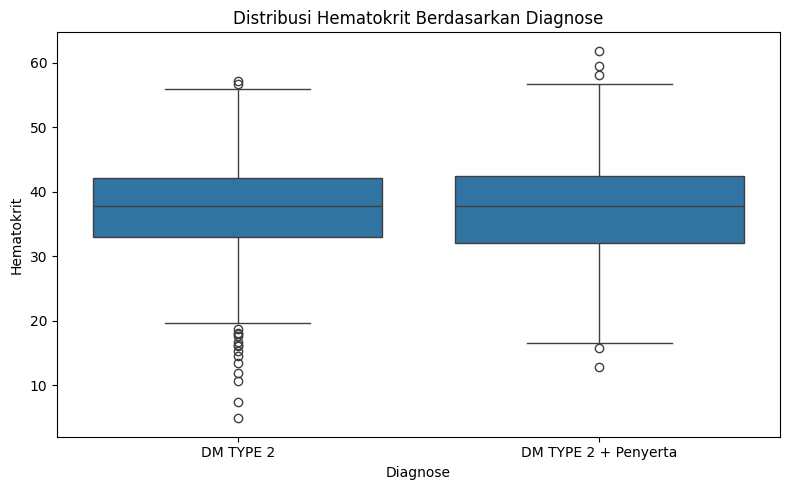

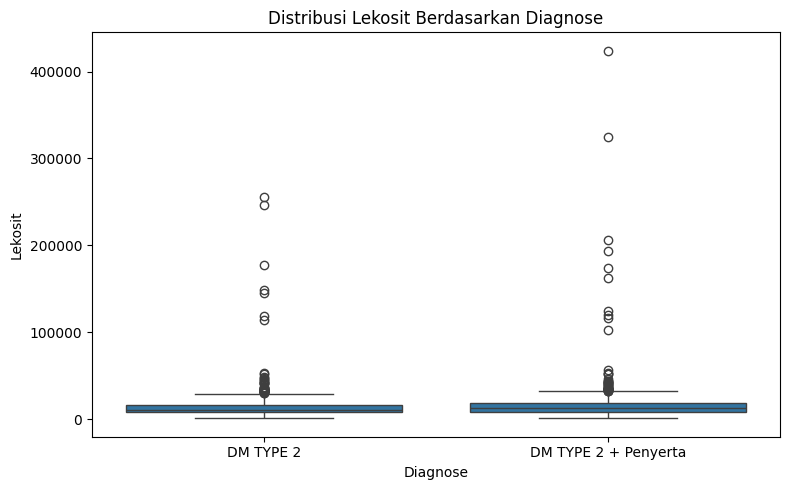

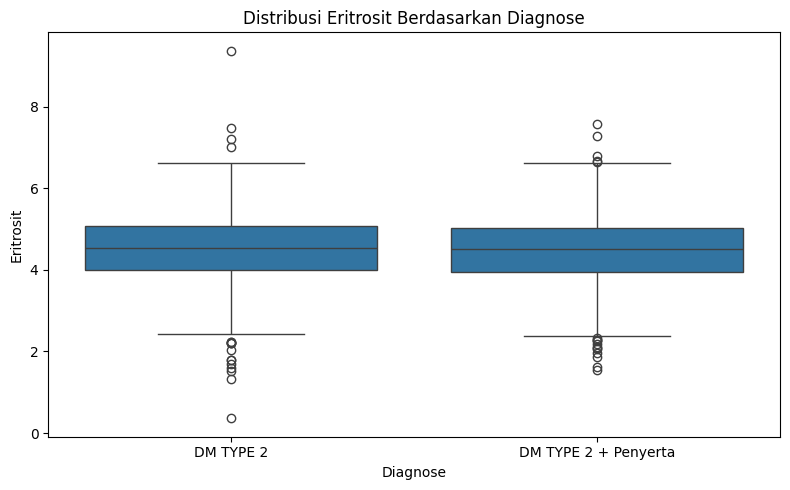

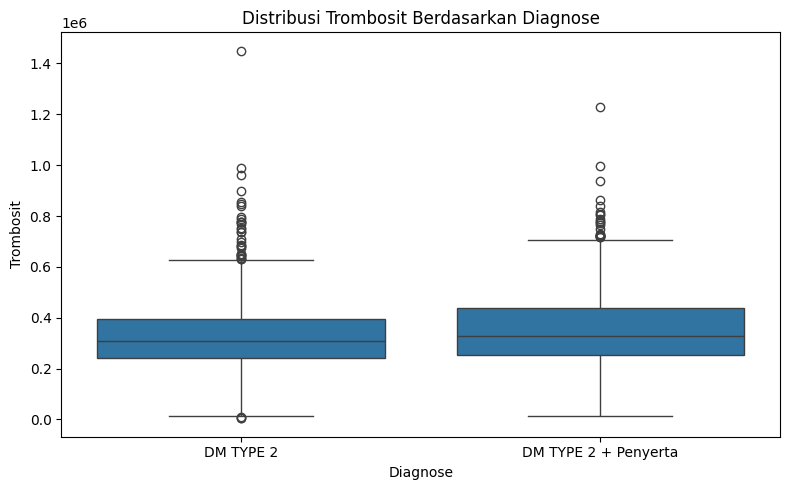

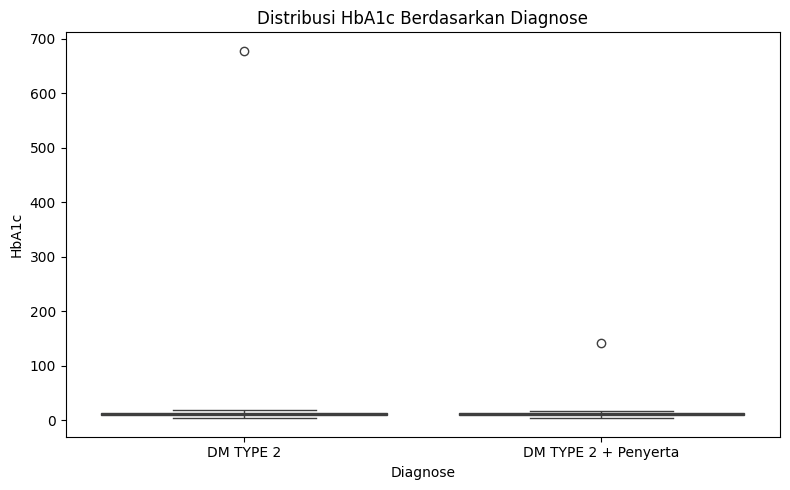

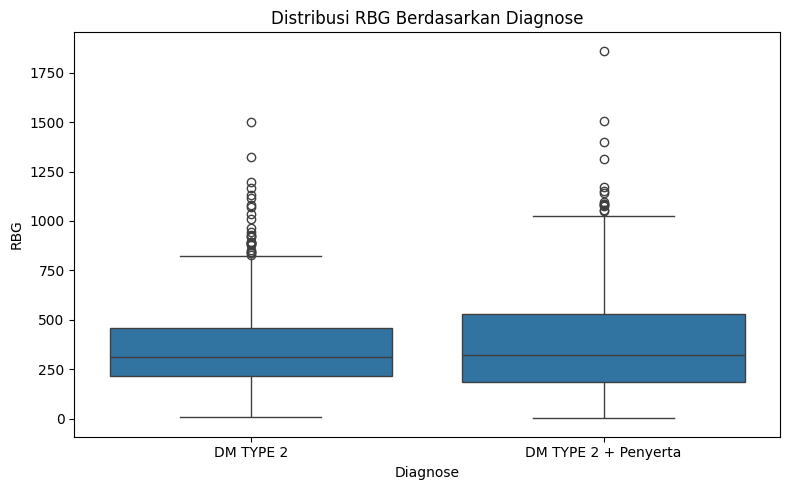

In [8]:
print("Statistik Berdasarkan Diagnose:")
print(df.groupby('Diagnose')[num_cols].describe())

# Visualisasi numerik berdasarkan diagnose (Boxplot)
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Diagnose', y=col)
    plt.title(f'Distribusi {col} Berdasarkan Diagnose')
    plt.tight_layout()
    plt.show()

##### SOAL 5: Uji Korelasi Pearson

Matriks Korelasi Pearson:
                 Age  Hemoglobin  Hematokrit   Lekosit  Eritrosit  Trombosit  \
Age         1.000000   -0.128288   -0.103052 -0.019124  -0.156953  -0.064933   
Hemoglobin -0.128288    1.000000    0.960731 -0.024770   0.854225  -0.233794   
Hematokrit -0.103052    0.960731    1.000000 -0.026387   0.876146  -0.211081   
Lekosit    -0.019124   -0.024770   -0.026387  1.000000  -0.025280   0.149668   
Eritrosit  -0.156953    0.854225    0.876146 -0.025280   1.000000  -0.154431   
Trombosit  -0.064933   -0.233794   -0.211081  0.149668  -0.154431   1.000000   
HbA1c      -0.059762    0.060214    0.052169  0.007266   0.030096  -0.003603   
RBG        -0.125535    0.166584    0.147539  0.146856   0.158468   0.024034   

               HbA1c       RBG  
Age        -0.059762 -0.125535  
Hemoglobin  0.060214  0.166584  
Hematokrit  0.052169  0.147539  
Lekosit     0.007266  0.146856  
Eritrosit   0.030096  0.158468  
Trombosit  -0.003603  0.024034  
HbA1c       1.000000  

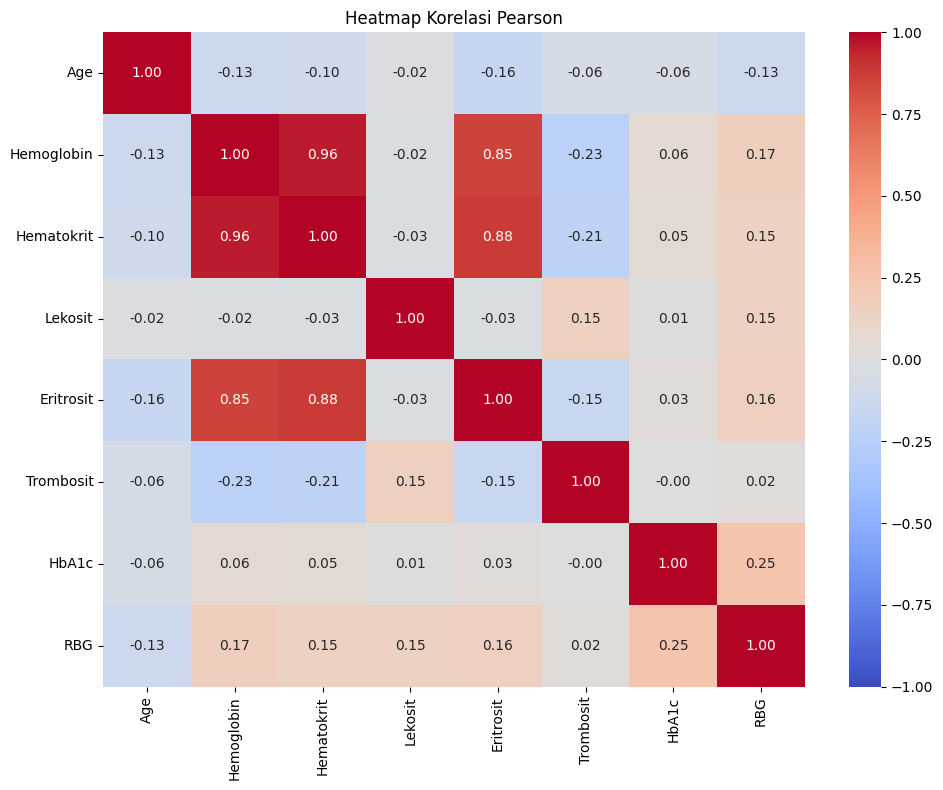

In [9]:
pearson_corr = df[num_cols].corr(method='pearson') # .corr() mengabaikan baris dengan NaN untuk perhitungan berpasangan
print("Matriks Korelasi Pearson:")
print(pearson_corr)

# Visualisasi Heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Pearson')
plt.tight_layout()
plt.show()

##### SOAL 6: Deteksi Outlier (Lower & Upper Bound) Per Diagnose

In [15]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

diagnose_groups = df['Diagnose'].dropna().unique()

for diag in diagnose_groups:
    print(f"\n>> Diagnose: {diag}")
    df_subset = df[df['Diagnose'] == diag]
    
    for col in num_cols:
        col_data = df_subset[col].dropna()
        if len(col_data) > 0:
            outliers, lb, ub = detect_outliers_iqr(col_data)
            if not outliers.empty:
                # print(f"  - {col}: {len(outliers)} outlier terdeteksi. (Batas: {lb:.2f} s/d {ub:.2f})")
                print(f"    Nilai: {outliers.values}")
            else:
                print(f"  - {col}: Tidak ada outlier.")


>> Diagnose: DM TYPE 2
    Nilai: [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1 21 21 22 23 23 24 24 24 24 25
 89]
    Nilai: [19.3  5.5  5.3  4.5  6.3  2.9  6.1  2.1  5.6  4.3  6.2  4.5  5.3  4.8]
    Nilai: [ 7.48 16.1  18.2  16.3  57.2  16.7  13.5  10.7  17.7   4.9  56.8  17.9
 11.9  18.7  15.4  14.6 ]
    Nilai: [ 40470.  35150.  34850.  45480.  33760.  32150.  43430. 255650.  31290.
  33290.  33540.  47240.  29790.  31930.  42220.  36290.  31410.  52290.
  41830.  32080.  32440.  35440.  41770.  33020.  31380.  33450.  48050.
  33020.  32660.  35890.  35120. 145000. 119000.  36630.  32570. 246000.
  53430. 149000.  42870.  46830.  29700.  31310. 113950. 178000.]
    Nilai: [7.48 1.8  2.22 1.78 9.37 2.04 1.69 1.53 2.23 0.36 7.02 2.21 1.32 2.2
 2.21 7.2  1.59]
    Nilai: [ 681000.  650000.    5400.  710000.  960000.    4300.  634000.  777000.
    7900.  648000.  644000.  839000.  739000.  674000.  684000.  631000.
  685000.  696000.  644000.  787000.  776000.  777000.  748000.  849000